In [1]:
from openaq import OpenAQ as aq
import pandas as pd

In [2]:
client = aq(api_key="703567a9b637449ffb21acf96659f4a58d69761753e4e1082ab6fb84232652de")

In [4]:
locations_resp = client.locations.list(
    countries_id=[9], 
    limit=1000
)

# Convert results to a list of dictionaries for Pandas
locs_data = [loc for loc in locations_resp.results]
df = pd.DataFrame(locs_data)

print(f"Found {len(df_locations)} stations in India.")

Found 703 stations in India.


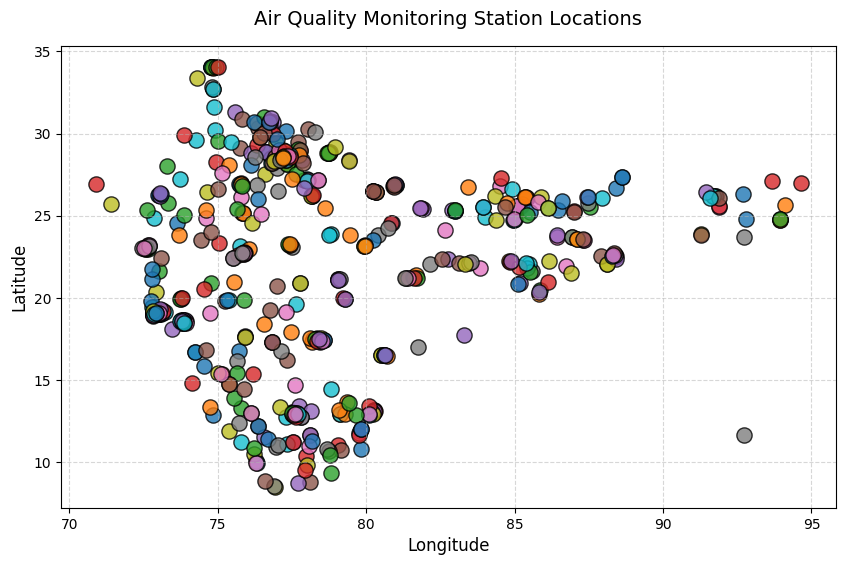

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract latitude and longitude from the 'coordinates' dictionary column
df['latitude'] = df['coordinates'].apply(lambda x: x['latitude'] if isinstance(x, dict) else None)
df['longitude'] = df['coordinates'].apply(lambda x: x['longitude'] if isinstance(x, dict) else None)

# 2. Plotting - Plotting each station as a series for an automatic legend
plt.figure(figsize=(10, 6))

for i, row in df.iterrows():
    if pd.notnull(row['longitude']) and pd.notnull(row['latitude']):
        plt.scatter(row['longitude'], row['latitude'], label=row['name'], s=120, edgecolors='black', alpha=0.8)

# 3. Formatting
plt.title('Air Quality Monitoring Station Locations', fontsize=14, pad=15)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Move the legend outside the plot area to keep the "map" clean
# plt.legend(title="Station Names", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.show()

In [1]:
from openaq import OpenAQ as aq
# OpenAQ is a Python class that provides access to communicate with API resources.
client = aq(api_key="703567a9b637449ffb21acf96659f4a58d69761753e4e1082ab6fb84232652de")
# Here the client variable will be an instance of the class OpenAQ.

In [15]:
response = client.locations.list(
        countries_id=[9], 
        limit=1000
    )

df = pd.DataFrame(response.results)

In [23]:
response = client.parameters.list()

df = pd.DataFrame(response.results)

In [25]:
df

,id,name,units,display_name,description
0,1,pm10,µg/m³,PM10,Particulate matter less than 10 micrometers in...
1,2,pm25,µg/m³,PM2.5,Particulate matter less than 2.5 micrometers i...
2,3,o3,µg/m³,O₃ mass,Ozone mass concentration
3,4,co,µg/m³,CO mass,Carbon Monoxide mass concentration
4,5,no2,µg/m³,NO₂ mass,Nitrogen Dioxide mass concentration
5,6,so2,µg/m³,SO₂ mass,Sulfur Dioxide mass concentration
6,7,no2,ppm,NO₂,Nitrogen Dioxide concentration
7,8,co,ppm,CO,Carbon Monoxide concentration
8,9,so2,ppm,SO₂,Sulfur Dioxide concentration
9,10,o3,ppm,O₃,Ozone concentration


In [29]:
# Get metadata for India (ID: 9)
response = client.countries.get(9)
india_info = response.results[0]

print(f"Country: {india_info.name}")
print(f"Data available from: {india_info.datetime_first}")
print(f"Most recent data:    {india_info.datetime_last}")

Country: India
Data available from: 2016-01-30T00:30:00Z
Most recent data:    2026-03-06T07:00:00Z


In [2]:

# Get a specific location in India (e.g., New Delhi station ID 8118)
response = client.locations.get(8118)
location = response.results[0]

for sensor in location.sensors:
    # Coverage often lists expected vs observed counts
    # If a sensor expects 24 measurements in a day, the resolution is 1 hour.
    print(f"Sensor ID: {sensor.id} | Parameter: {sensor.parameter.name}")
    print(f"Coverage Info: {sensor.coverage}")

Sensor ID: 23534 | Parameter: pm25


AttributeError: 'SensorBase' object has no attribute 'coverage'

In [7]:
import openaq
import pandas as pd

def get_location_timeseries(client, location_id, parameter_ids, date_from, date_to):
    """
    Fetches time series data for a location and pivots it into a clean DataFrame.
    """
    all_measurements = []
    
    # Fetch measurements for the location
    # We filter by the specific parameters requested
    response = client.measurements.list(
        location_id=location_id,
        parameters_id=parameter_ids,
        date_from=date_from,
        date_to=date_to,
        limit=1000  # Adjust limit or add pagination for long time ranges
    )
    
    for m in response.results:
        all_measurements.append({
            "timestamp": m.period.datetime_to.utc,
            "parameter": m.parameter.name,
            "value": m.value
        })
    
    if not all_measurements:
        return pd.DataFrame()

    # Convert to DataFrame
    df_raw = pd.DataFrame(all_measurements)
    
    # Convert timestamp to actual datetime objects
    df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
    
    # Pivot: Index = Time, Columns = Parameters (pm25, pm10, no2)
    df_pivot = df_raw.pivot_table(
        index='timestamp', 
        columns='parameter', 
        values='value', 
        aggfunc='mean' # Use mean in case of duplicate timestamps
    )
    
    return df_pivot.sort_index()

# --- Usage Example ---
api_key = "YOUR_API_KEY"
client = openaq.OpenAQ(api_key=api_key)

# Define variables: PM25=2, PM10=1, NO2=7
target_params = [1, 2, 7] 
loc_id = 8118 # Example: A station in Delhi

df_delhi = get_location_timeseries(
    client, 
    location_id=loc_id, 
    parameter_ids=target_params,
    date_from="2026-03-01T00:00:00Z",
    date_to="2026-03-05T00:00:00Z"
)

print(df_delhi.head())

TypeError: Measurements.list() got an unexpected keyword argument 'location_id'

In [9]:
import openaq
import pandas as pd

def get_location_timeseries(client, location_id, target_param_names, dt_from, dt_to):
    """
    1. Finds sensor IDs for specific parameters at a location.
    2. Fetches time series for each sensor.
    3. Merges them into a single DataFrame.
    """
    # Step 1: Get the location details to find the Sensor IDs
    loc_details = client.locations.get(location_id)
    if not loc_details.results:
        print("Location not found.")
        return pd.DataFrame()

    # Create a mapping of {parameter_name: sensor_id}
    # e.g., {'pm25': 123, 'no2': 456}
    sensor_map = {
        s.parameter.name: s.id 
        for s in loc_details.results[0].sensors 
        if s.parameter.name in target_param_names
    }

    all_dfs = []

    # Step 2: Loop through the sensors found and get measurements
    for param_name, s_id in sensor_map.items():
        try:
            res = client.measurements.list(
                sensors_id=s_id,
                datetime_from=dt_from,
                datetime_to=dt_to,
                limit=1000
            )
            
            if res.results:
                # Extract data into a temporary list
                tmp_data = [
                    {"timestamp": m.period.datetime_to.utc, param_name: m.value} 
                    for m in res.results
                ]
                # Convert to DF and set index to timestamp
                tmp_df = pd.DataFrame(tmp_data)
                tmp_df['timestamp'] = pd.to_datetime(tmp_df['timestamp'])
                tmp_df.set_index('timestamp', inplace=True)
                all_dfs.append(tmp_df)
        
        except Exception as e:
            print(f"Could not fetch {param_name} for sensor {s_id}: {e}")

    # Step 3: Combine all parameter DataFrames into one
    if not all_dfs:
        return pd.DataFrame()
    
    # Concatenate columns based on the timestamp index
    final_df = pd.concat(all_dfs, axis=1)
    return final_df.sort_index()

# --- Execution ---
client = openaq.OpenAQ(api_key="703567a9b637449ffb21acf96659f4a58d69761753e4e1082ab6fb84232652de")

# Note: Use the string names as defined in the OpenAQ parameters list
params = ['pm25', 'pm10', 'no2']

df = get_location_timeseries(
    client, 
    location_id=8118, 
    target_param_names=params,
    dt_from="2026-03-01T00:00:00Z",
    dt_to="2026-03-05T00:00:00Z"
)

print(df.head())

                            pm25
timestamp                       
2026-03-01 00:30:00+00:00   91.0
2026-03-01 01:30:00+00:00   95.0
2026-03-01 02:30:00+00:00  100.0
2026-03-01 03:30:00+00:00   96.0
2026-03-01 04:30:00+00:00   92.0


In [10]:
df

,pm25
timestamp,
2026-03-01 00:30:00+00:00,91.0
2026-03-01 01:30:00+00:00,95.0
2026-03-01 02:30:00+00:00,100.0
2026-03-01 03:30:00+00:00,96.0
2026-03-01 04:30:00+00:00,92.0
...,...
2026-03-04 19:30:00+00:00,44.0
2026-03-04 20:30:00+00:00,60.0
2026-03-04 21:30:00+00:00,78.0
